# Parameter Scan Analysis
This notebook analyzes the results from the parameter scan files in the repository. It loads, summarizes, visualizes, and compares the scan results to help identify optimal parameter sets.

In [1]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load Scan Files
Load the parameter scan summary CSV files into pandas DataFrames.

In [2]:
# Load the parameter scan summary CSV files into pandas DataFrames
scan_files = [
    'scan_summary_manualRBF_noplasticinput.csv',
    'scan_summary_manualRBF_plasticinput.csv',
    'scan_summary_rbneuron_noplasticinput_buffersize10.csv',
    'scan_summary_rbneuron_noplasticinput_buffersize25.csv',
    'scan_summary_rbneuron_noplasticinput_buffersize50.csv',
    'scan_summary_rbneuron_plasticinput_buffersize50.csv',
 ]
dfs = [pd.read_csv(f) for f in scan_files]
# Print the shape of each loaded DataFrame
for i, df in enumerate(dfs):
    print(f"Loaded {scan_files[i]}: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded scan_summary_manualRBF_noplasticinput.csv: 2700 rows, 69 columns
Loaded scan_summary_manualRBF_plasticinput.csv: 2700 rows, 69 columns
Loaded scan_summary_rbneuron_noplasticinput_buffersize10.csv: 1885 rows, 72 columns
Loaded scan_summary_rbneuron_noplasticinput_buffersize25.csv: 2700 rows, 72 columns
Loaded scan_summary_rbneuron_noplasticinput_buffersize50.csv: 2700 rows, 72 columns
Loaded scan_summary_rbneuron_plasticinput_buffersize50.csv: 2700 rows, 72 columns


## Identify Best Parameter Sets
Apply selection criteria (e.g., lowest error) to identify and display the best parameter sets from the scans.

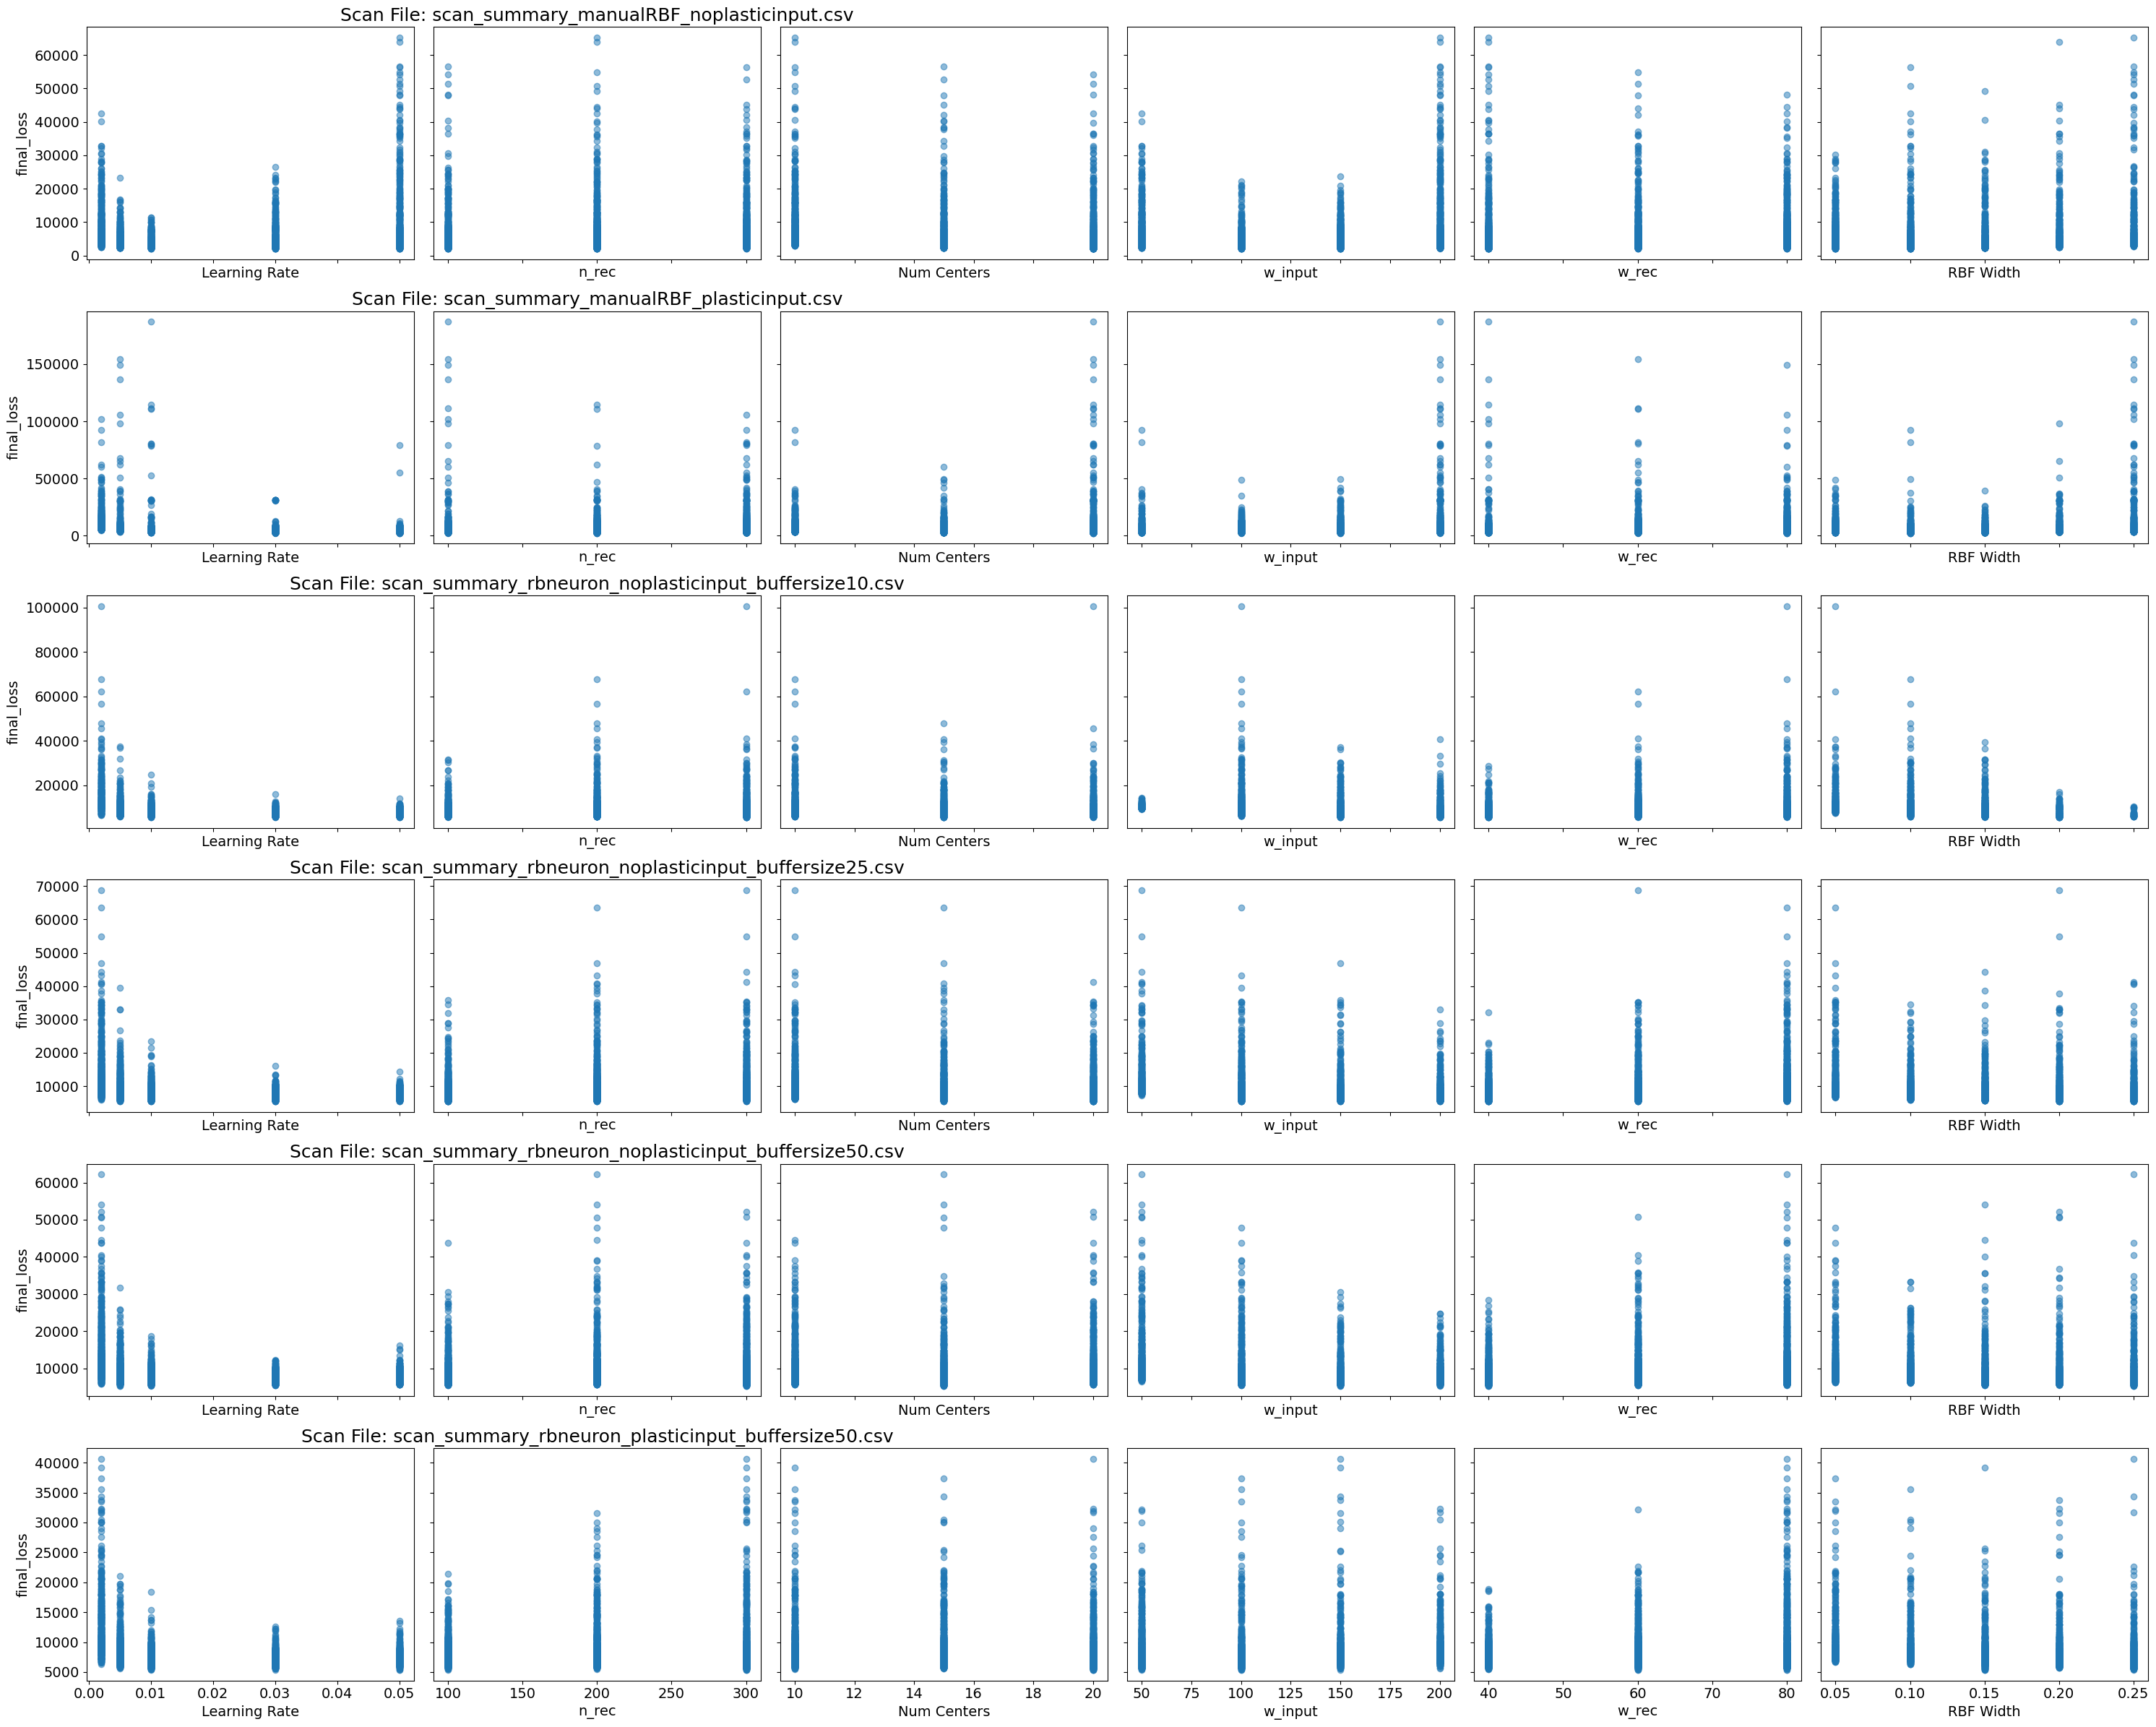

In [3]:
# Scatter plots: each row is a scan file, each column is a scanned parameter
param_names = ['synapses.exc.optimizer.eta', 'neurons.n_rec', 'rbf.num_centers', 'synapses.w_input', 'synapses.w_rec', 'rbf.width']
param_labels = ['Learning Rate', 'n_rec', 'Num Centers', 'w_input', 'w_rec', 'RBF Width']
params_to_plot = [p for p in param_names if all(p in df.columns for df in dfs)]
n_files = len(dfs)
n_params = len(params_to_plot)
# Create a grid of subplots: rows=scan files, columns=parameters
fig, axes = plt.subplots(n_files, n_params, figsize=(5 * n_params, 4 * n_files), sharey='row', sharex='col')
for row, df in enumerate(dfs):
    for col, param in enumerate(params_to_plot):
        ax = axes[row, col] if n_files > 1 else axes[col]
        ax.scatter(df[param], df['final_loss'], alpha=0.5)
        ax.set_xlabel(param_labels[col])
        if col == 0:
            ax.set_ylabel('final_loss')
        else:
            ax.set_ylabel('')
    # Set a title for each row of subplots (first column only)
    axes[row, 1].set_title(f'Scan File: {scan_files[row]}', fontsize=18)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)

plt.tight_layout()
plt.show()

In [4]:
# Print the best parameter set (lowest final_loss) for each scan file
key_params = ['synapses.exc.optimizer.eta', 'neurons.n_rec', 'rbf.num_centers', 'synapses.w_input', 'synapses.w_rec', 'rbf.width']
for i, df in enumerate(dfs):
    print(f'Best run for {scan_files[i]}:')
    best_idx = df['final_loss'].idxmin()
    best_row = df.loc[best_idx]
# Print each key parameter value for the best run
    for param in key_params:
        if param in df.columns:
            print(f'  {param}: {best_row[param]}')
    print(f'  final_loss: {best_row["final_loss"]}')
    print('-' * 40)

Best run for scan_summary_manualRBF_noplasticinput.csv:
  synapses.exc.optimizer.eta: 0.03
  neurons.n_rec: 100.0
  rbf.num_centers: 20.0
  synapses.w_input: 150.0
  synapses.w_rec: 40.0
  rbf.width: 0.05
  final_loss: 2005.4654403501409
----------------------------------------
Best run for scan_summary_manualRBF_plasticinput.csv:
  synapses.exc.optimizer.eta: 0.05
  neurons.n_rec: 200.0
  rbf.num_centers: 20.0
  synapses.w_input: 150.0
  synapses.w_rec: 60.0
  rbf.width: 0.1
  final_loss: 2318.2128631695023
----------------------------------------
Best run for scan_summary_rbneuron_noplasticinput_buffersize10.csv:
  synapses.exc.optimizer.eta: 0.03
  neurons.n_rec: 300.0
  rbf.num_centers: 15.0
  synapses.w_input: 150.0
  synapses.w_rec: 40.0
  rbf.width: 0.2
  final_loss: 5663.094834049872
----------------------------------------
Best run for scan_summary_rbneuron_noplasticinput_buffersize25.csv:
  synapses.exc.optimizer.eta: 0.01
  neurons.n_rec: 100.0
  rbf.num_centers: 20.0
  syna

In [5]:
for idx, df in enumerate(dfs):
	print(f"Top 5 'folder' entries for {scan_files[idx]} (lowest final_loss):")
	top5 = df.nsmallest(5, 'final_loss')
	for i, (folder, loss) in enumerate(zip(top5['folder'], top5['final_loss'])):
		print(f"  {i+1}. {folder} (final_loss: {loss:.4f})")
	print('-' * 40)

Top 5 'folder' entries for scan_summary_manualRBF_noplasticinput.csv (lowest final_loss):
  1. neurons_n_rec_100.0_task_n_iter_500.0_rbf_num_centers_20.0_synapses_w_input_150.0_synapses_w_rec_40.0_rbf_width_0.05_lr_exc_0.03_plastic_False_manualRBF_True (final_loss: 2005.4654)
  2. neurons_n_rec_200.0_task_n_iter_500.0_rbf_num_centers_20.0_synapses_w_input_100.0_synapses_w_rec_40.0_rbf_width_0.1_lr_exc_0.03_plastic_False_manualRBF_True (final_loss: 2012.4463)
  3. neurons_n_rec_100.0_task_n_iter_500.0_rbf_num_centers_20.0_synapses_w_input_150.0_synapses_w_rec_40.0_rbf_width_0.05_lr_exc_0.05_plastic_False_manualRBF_True (final_loss: 2031.9973)
  4. neurons_n_rec_100.0_task_n_iter_500.0_rbf_num_centers_20.0_synapses_w_input_150.0_synapses_w_rec_60.0_rbf_width_0.05_lr_exc_0.03_plastic_False_manualRBF_True (final_loss: 2033.8915)
  5. neurons_n_rec_200.0_task_n_iter_500.0_rbf_num_centers_20.0_synapses_w_input_150.0_synapses_w_rec_40.0_rbf_width_0.1_lr_exc_0.01_plastic_False_manualRBF_True (